# Sensitivity Analysis: Review + Pre-Application Levels

This notebook runs the permit simulation under:
- 3 levels (e.g., 50%, 100%, 200%) for review stages
  - Planning
  - Public works
  - Fire
  - Special zoning
  - Agency referral
- multiple pre-application distribution options
  - baseline
  - lognormal_180
  - lognormal_60
  - poisson_10
  - lognormal_10

Levels scale review durations, and planning/public works staffing can also be set
from baseline staff values (`PLANNING_STAFF_BASELINE`, `PUBLIC_WORKS_STAFF_BASELINE`).

It evaluates every selected combination and summarizes outcomes (e.g., mean total days, waiting/service, county vs applicant days).

In [1]:
import itertools
import json
import time
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from run_simulation import run_simulation
from visualize_permits import calculate_step_waiting_service_totals

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
def run_duration_level_sensitivity(
    n_runs: int,
    num_permits: int,
    levels: list[float],
    pre_app_distributions: list[str],
    inter_arrival_time: float = 0.0,
    sequential: str = "standard",
    base_seed: int = 42,
    planning_staff_baseline: int = 20,
    public_works_staff_baseline: int = 30,
    fire_staff_baseline: int = 10,
    planning_caseload_per_staff: float = 7,
    public_works_caseload_per_staff: float = 7,
    fire_caseload_per_staff: float = 7,
):
    rows = []

    stages = [
        "planning",
        "public_works",
        "fire",
        "special_zoning",
        "agency_referral",
    ]
    step_names = [
        "EPA Debris",
        "USACE Debris",
        "Pre-Application Activities",
        "Applicant Revisions",
        "Planning",
        "Agency Referral",
        "Special Zoning",
        "Public Works",
        "Fire Review",
    ]
    level_combos = list(itertools.product(levels, repeat=len(stages)))

    total_runs = len(pre_app_distributions) * len(level_combos) * n_runs
    completed_runs = 0
    start_time = time.time()

    for pre_app_dist in pre_app_distributions:
        for combo_vals in level_combos:
            multiplier_map = dict(zip(stages, combo_vals))
            planning_staff_count = max(1, int(round(planning_staff_baseline * multiplier_map["planning"])))
            public_works_staff_count = max(
                1, int(round(public_works_staff_baseline * multiplier_map["public_works"]))
            )
            fire_staff_count = max(1, int(round(fire_staff_baseline)))

            combo_name = (
                f"pre_app={pre_app_dist} | "
                + " | ".join(f"{k}={v:.1f}x" for k, v in multiplier_map.items())
            )
            combo_name += (
                f" | planning_staff={planning_staff_count}"
                f" | public_works_staff={public_works_staff_count}"
                f" | fire_staff={fire_staff_count}"
            )

            for run_idx in range(n_runs):
                seed = base_seed + run_idx
                sim = run_simulation(
                    num_permits=num_permits,
                    random_seed=seed,
                    inter_arrival_time=inter_arrival_time,
                    sequential=sequential,
                    review_duration_multipliers=multiplier_map,
                    pre_application_distribution=pre_app_dist,
                    planning_staff_count=planning_staff_count,
                    public_works_staff_count=public_works_staff_count,
                    planning_caseload_per_staff=planning_caseload_per_staff,
                    public_works_caseload_per_staff=public_works_caseload_per_staff,
                    fire_staff_count=fire_staff_count,
                    fire_caseload_per_staff=fire_caseload_per_staff,
                )
                stats = sim.get_statistics()
                completed_runs += 1
                if completed_runs % 1000 == 0 or completed_runs == total_runs:
                    elapsed = time.time() - start_time
                    avg_per_run = elapsed / completed_runs if completed_runs else 0.0
                    remaining = max(total_runs - completed_runs, 0)
                    eta_sec = remaining * avg_per_run
                    print(
                        f"Progress: {completed_runs}/{total_runs} runs "
                        f"({100.0 * completed_runs / total_runs:.1f}%) | "
                        f"elapsed {elapsed / 60:.1f} min | ETA {eta_sec / 60:.1f} min"
                    )

                if "message" in stats:
                    continue

                avg_total = stats.get("average_total_time") or {}
                total_wait = stats.get("total_waiting_time") or {}
                total_service = stats.get("total_service_time") or {}
                county_vs_app = stats.get("county_review_vs_applicant") or {}

                # Mean waiting/service time per permit for each step
                permits = sim.completed_permits
                n_permits = len(permits)

                # Planning-to-ready metric: from planning start to ready for construction
                planning_to_ready_days = [
                    (p.ready_for_construction - p.planning_request)
                    for p in permits
                    if p.planning_request is not None and p.ready_for_construction is not None
                ]
                mean_planning_to_ready_days = (
                    float(np.mean(planning_to_ready_days))
                    if planning_to_ready_days
                    else np.nan
                )

                # Debris gating metric: if debris ends after ready_for_construction,
                # permit would wait this additional time before construction can truly start.
                debris_blocking_wait_days = [
                    (p.debris_removal_end - p.ready_for_construction)
                    for p in permits
                    if p.debris_removal_end is not None
                    and p.ready_for_construction is not None
                    and p.debris_removal_end > p.ready_for_construction
                ]
                debris_blocking_wait_count = len(debris_blocking_wait_days)
                debris_blocking_wait_mean = (
                    float(np.mean(debris_blocking_wait_days))
                    if debris_blocking_wait_days
                    else 0.0
                )
                debris_blocking_wait_median = (
                    float(np.median(debris_blocking_wait_days))
                    if debris_blocking_wait_days
                    else 0.0
                )
                debris_blocking_wait_max = (
                    float(np.max(debris_blocking_wait_days))
                    if debris_blocking_wait_days
                    else 0.0
                )

                wait_sums = {s: 0.0 for s in step_names}
                service_sums = {s: 0.0 for s in step_names}
                for p in permits:
                    step_data = calculate_step_waiting_service_totals(p)
                    for s in step_names:
                        vals = step_data.get(s, {"waiting": 0.0, "service": 0.0})
                        wait_sums[s] += vals.get("waiting", 0.0)
                        service_sums[s] += vals.get("service", 0.0)

                step_cols = {}
                for s in step_names:
                    col_key = s.lower().replace(" ", "_").replace("-", "_")
                    denom = n_permits if n_permits > 0 else 1
                    step_cols[f"step_wait_mean__{col_key}"] = wait_sums[s] / denom
                    step_cols[f"step_service_mean__{col_key}"] = service_sums[s] / denom

                rows.append(
                    {
                        "combo": combo_name,
                        "pre_application_distribution": pre_app_dist,
                        "planning_staff_count": planning_staff_count,
                        "public_works_staff_count": public_works_staff_count,
                        "fire_staff_count": fire_staff_count,
                        "planning_level": multiplier_map["planning"],
                        "public_works_level": multiplier_map["public_works"],
                        "fire_level": multiplier_map["fire"],
                        "special_zoning_level": multiplier_map["special_zoning"],
                        "agency_referral_level": multiplier_map["agency_referral"],
                        "run": run_idx,
                        "seed": seed,
                        "completed_permits": n_permits,
                        "mean_total_days": avg_total.get("mean", np.nan),
                        "mean_application_to_ready_days": mean_planning_to_ready_days,
                        "planning_to_ready_n": len(planning_to_ready_days),
                        "debris_blocking_wait_count": debris_blocking_wait_count,
                        "debris_blocking_wait_share": (
                            debris_blocking_wait_count / n_permits if n_permits > 0 else np.nan
                        ),
                        "debris_blocking_wait_mean_days": debris_blocking_wait_mean,
                        "debris_blocking_wait_median_days": debris_blocking_wait_median,
                        "debris_blocking_wait_max_days": debris_blocking_wait_max,
                        "median_total_days": avg_total.get("median", np.nan),
                        "std_total_days": avg_total.get("std", np.nan),
                        "min_total_days": avg_total.get("min", np.nan),
                        "max_total_days": avg_total.get("max", np.nan),
                        "mean_wait_days": total_wait.get("mean", np.nan),
                        "mean_service_days": total_service.get("mean", np.nan),
                        "county_review_mean": county_vs_app.get("county_review_mean", np.nan),
                        "applicant_mean": county_vs_app.get("applicant_mean", np.nan),
                        "debris_mean": county_vs_app.get("debris_mean", np.nan),
                        "stats_json": json.dumps(stats),
                        **step_cols,
                    }
                )

    return pd.DataFrame(rows)

In [3]:
# --- Experiment settings ---
levels = [0.5, 1.0, 2.0]  # 50%, 100%, 150%
pre_app_distributions = ["lognormal_180", "lognormal_60", "lognormal_10"]
# Add "baseline" to the list above if you want to include the original model behavior.

N_RUNS = 10
N_PERMITS = 1200
INTER_ARRIVAL = 0.0
SEQUENTIAL_MODE = "standard"  # "standard", "parallel", or "sequential"

# Planning/public works levels are interpreted as staff-count multipliers.
PLANNING_STAFF_BASELINE = 8
PUBLIC_WORKS_STAFF_BASELINE = 16
FIRE_STAFF_BASELINE = 4
PLANNING_CASELOAD_PER_STAFF = 7
PUBLIC_WORKS_CASELOAD_PER_STAFF = 7
FIRE_CASELOAD_PER_STAFF = 7

results_df = run_duration_level_sensitivity(
    n_runs=N_RUNS,
    num_permits=N_PERMITS,
    levels=levels,
    pre_app_distributions=pre_app_distributions,
    inter_arrival_time=INTER_ARRIVAL,
    sequential=SEQUENTIAL_MODE,
    base_seed=42,
    planning_staff_baseline=PLANNING_STAFF_BASELINE,
    public_works_staff_baseline=PUBLIC_WORKS_STAFF_BASELINE,
    fire_staff_baseline=FIRE_STAFF_BASELINE,
    planning_caseload_per_staff=PLANNING_CASELOAD_PER_STAFF,
    public_works_caseload_per_staff=PUBLIC_WORKS_CASELOAD_PER_STAFF,
    fire_caseload_per_staff=FIRE_CASELOAD_PER_STAFF,
)

print(f"Rows: {len(results_df)}")
print(f"Unique combinations: {results_df['combo'].nunique()}")
print(f"Expected combinations: {len(pre_app_distributions) * (len(levels) ** 5)}")
results_df.head()

Progress: 1000/7290 runs (13.7%) | elapsed 3.8 min | ETA 23.6 min
Progress: 2000/7290 runs (27.4%) | elapsed 7.4 min | ETA 19.6 min
Progress: 3000/7290 runs (41.2%) | elapsed 11.3 min | ETA 16.1 min
Progress: 4000/7290 runs (54.9%) | elapsed 15.2 min | ETA 12.5 min
Progress: 5000/7290 runs (68.6%) | elapsed 19.2 min | ETA 8.8 min
Progress: 6000/7290 runs (82.3%) | elapsed 25.8 min | ETA 5.6 min
Progress: 7000/7290 runs (96.0%) | elapsed 29.7 min | ETA 1.2 min
Progress: 7290/7290 runs (100.0%) | elapsed 30.9 min | ETA 0.0 min
Rows: 7290
Unique combinations: 729
Expected combinations: 729


,combo,pre_application_distribution,planning_staff_count,public_works_staff_count,fire_staff_count,planning_level,public_works_level,fire_level,special_zoning_level,agency_referral_level,run,seed,completed_permits,mean_total_days,mean_application_to_ready_days,planning_to_ready_n,debris_blocking_wait_count,debris_blocking_wait_share,debris_blocking_wait_mean_days,debris_blocking_wait_median_days,debris_blocking_wait_max_days,median_total_days,std_total_days,min_total_days,max_total_days,mean_wait_days,mean_service_days,county_review_mean,applicant_mean,debris_mean,stats_json,step_wait_mean__epa_debris,step_service_mean__epa_debris,step_wait_mean__usace_debris,step_service_mean__usace_debris,step_wait_mean__pre_application_activities,step_service_mean__pre_application_activities,step_wait_mean__applicant_revisions,step_service_mean__applicant_revisions,step_wait_mean__planning,step_service_mean__planning,step_wait_mean__agency_referral,step_service_mean__agency_referral,step_wait_mean__special_zoning,step_service_mean__special_zoning,step_wait_mean__public_works,step_service_mean__public_works,step_wait_mean__fire_review,step_service_mean__fire_review
0,pre_app=lognormal_180 | planning=0.5x | public...,lognormal_180,4,8,4,0.5,0.5,0.5,0.5,0.5,0,42,1200,288.993904,77.998754,1200,0,0.0,0.0,0.0,0.0,264.015618,126.148098,72.091020,1502.387691,11.284601,297.282156,19.473441,274.309495,14.783822,"{""total_completed"": 1200, ""total_in_progress"":...",3.235752,1.016461,8.039942,2.491667,0.0,210.995150,0.0,63.314345,0.008908,3.394252,0.0,3.963328,0.0,5.653323,0.0,4.142081,0.000000,2.311549
1,pre_app=lognormal_180 | planning=0.5x | public...,lognormal_180,4,8,4,0.5,0.5,0.5,0.5,0.5,1,43,1200,285.173312,77.236778,1200,0,0.0,0.0,0.0,0.0,260.263296,117.726819,63.522803,918.962668,11.455683,293.441556,18.680521,271.246238,14.970479,"{""total_completed"": 1200, ""total_in_progress"":...",3.214872,1.010328,8.231113,2.514167,0.0,207.936534,0.0,63.309704,0.009698,3.378659,0.0,3.725889,0.0,5.179561,0.0,4.135255,0.000000,2.251458
2,pre_app=lognormal_180 | planning=0.5x | public...,lognormal_180,4,8,4,0.5,0.5,0.5,0.5,0.5,2,44,1200,283.374593,77.017068,1200,0,0.0,0.0,0.0,0.0,256.123877,121.400488,85.706290,969.972895,11.260237,291.512638,18.522385,269.526079,14.724411,"{""total_completed"": 1200, ""total_in_progress"":...",3.137635,1.000832,8.110111,2.475833,0.0,206.357525,0.0,63.168553,0.011746,3.359761,0.0,3.598331,0.0,5.074457,0.0,4.133687,0.000745,2.343657
3,pre_app=lognormal_180 | planning=0.5x | public...,lognormal_180,4,8,4,0.5,0.5,0.5,0.5,0.5,3,45,1200,282.690418,78.036224,1200,0,0.0,0.0,0.0,0.0,256.666009,118.702439,74.927339,1037.075963,11.304179,290.894439,19.090798,268.309836,14.797985,"{""total_completed"": 1200, ""total_in_progress"":...",3.147904,1.007022,8.135558,2.507500,0.0,204.654194,0.0,63.655642,0.020475,3.415865,0.0,3.746621,0.0,5.476789,0.0,4.156475,0.000242,2.274332
4,pre_app=lognormal_180 | planning=0.5x | public...,lognormal_180,4,8,4,0.5,0.5,0.5,0.5,0.5,4,46,1200,284.539788,78.199659,1200,0,0.0,0.0,0.0,0.0,259.116044,125.578299,72.550399,1735.573238,11.271818,292.771247,19.611057,269.662447,14.769561,"{""total_completed"": 1200, ""total_in_progress"":...",3.226570,1.017454,8.038871,2.486667,0.0,206.340129,0.0,63.322318,0.006377,3.401229,0.0,3.689261,0.0,6.094389,0.0,4.157896,0.000000,2.261906


In [4]:
summary = (
    results_df
    .groupby([
        "pre_application_distribution",
        "planning_level",
        "public_works_level",
        "fire_level",
        "special_zoning_level",
        "agency_referral_level",
    ], as_index=False)
    .mean(numeric_only=True)
    .sort_values("mean_total_days")
    .reset_index(drop=True)
)

summary = summary.rename(columns={"run": "n_runs_proxy"})

print("Top 10 fastest combinations (by mean total days):")
display(summary.head(10))

print("Top 10 slowest combinations:")
display(summary.tail(10).sort_values("mean_total_days", ascending=False))

Top 10 fastest combinations (by mean total days):


,pre_application_distribution,planning_level,public_works_level,fire_level,special_zoning_level,agency_referral_level,planning_staff_count,public_works_staff_count,fire_staff_count,n_runs_proxy,seed,completed_permits,mean_total_days,mean_application_to_ready_days,planning_to_ready_n,debris_blocking_wait_count,debris_blocking_wait_share,debris_blocking_wait_mean_days,debris_blocking_wait_median_days,debris_blocking_wait_max_days,median_total_days,std_total_days,min_total_days,max_total_days,mean_wait_days,mean_service_days,county_review_mean,applicant_mean,debris_mean,step_wait_mean__epa_debris,step_service_mean__epa_debris,step_wait_mean__usace_debris,step_service_mean__usace_debris,step_wait_mean__pre_application_activities,step_service_mean__pre_application_activities,step_wait_mean__applicant_revisions,step_service_mean__applicant_revisions,step_wait_mean__planning,step_service_mean__planning,step_wait_mean__agency_referral,step_service_mean__agency_referral,step_wait_mean__special_zoning,step_service_mean__special_zoning,step_wait_mean__public_works,step_service_mean__public_works,step_wait_mean__fire_review,step_service_mean__fire_review
0,lognormal_10,0.5,0.5,0.5,0.5,0.5,4.0,8.0,4.0,4.5,46.5,1200.0,156.662927,145.096385,1200.0,5.9,0.004917,10.008470,8.313668,20.529849,155.195208,57.174524,22.471901,377.661587,78.840077,97.450826,86.837889,74.600315,14.852699,3.145482,0.998964,8.210169,2.498083,0.0,11.566542,0.0,63.033773,67.477849,3.397923,0.0,3.821804,0.0,5.657351,0.000248,4.150675,0.006329,2.325711
1,lognormal_10,0.5,0.5,0.5,0.5,1.0,4.0,8.0,4.0,4.5,46.5,1200.0,158.822278,147.255737,1200.0,5.8,0.004833,10.049509,8.391778,20.529849,157.011567,59.246854,22.471901,437.500971,78.840077,101.272629,90.659693,74.600315,14.852699,3.145482,0.998964,8.210169,2.498083,0.0,11.566542,0.0,63.033773,67.477849,3.397923,0.0,7.643607,0.0,5.657351,0.000248,4.150675,0.006329,2.325711
2,lognormal_10,0.5,1.0,0.5,0.5,0.5,4.0,16.0,4.0,4.5,46.5,1200.0,161.475949,149.909408,1200.0,3.5,0.002917,9.580472,8.398299,15.988050,160.150333,57.176407,24.527888,369.392537,79.239553,102.227281,91.415830,75.184992,14.866012,3.156756,1.002453,8.207886,2.498917,0.0,11.566542,0.0,63.618450,67.870834,3.397754,0.0,3.789674,0.0,5.726607,0.000297,8.336705,0.003779,2.290179
3,lognormal_10,0.5,0.5,0.5,1.0,0.5,4.0,8.0,4.0,4.5,46.5,1200.0,162.898009,151.331467,1200.0,6.4,0.005333,9.671901,8.423830,19.112073,160.439424,63.261210,23.280160,498.774493,78.827730,103.779041,92.615595,75.137811,14.853366,3.145600,1.000679,8.210169,2.496917,0.0,11.566542,0.0,63.571269,67.468204,3.402294,0.0,3.767086,0.0,11.456714,0.000495,4.159922,0.003261,2.357619
4,lognormal_10,1.0,0.5,0.5,0.5,0.5,8.0,8.0,4.0,4.5,46.5,1200.0,163.382252,151.815710,1200.0,2.9,0.002417,9.667159,9.077817,16.269881,161.955655,59.942398,25.847223,368.088180,81.762075,101.212147,93.066814,75.051724,14.855684,3.162055,1.002451,8.195679,2.495500,0.0,11.566542,0.0,63.485183,70.401315,6.797049,0.0,3.671156,0.0,5.709685,0.000396,4.152824,0.002630,2.331757
5,lognormal_10,0.5,1.0,0.5,0.5,1.0,4.0,16.0,4.0,4.5,46.5,1200.0,163.599929,152.033388,1200.0,3.5,0.002917,9.580472,8.398299,15.988050,161.754572,59.251387,24.527888,445.627380,79.239553,106.016954,95.205503,75.184992,14.866012,3.156756,1.002453,8.207886,2.498917,0.0,11.566542,0.0,63.618450,67.870834,3.397754,0.0,7.579347,0.0,5.726607,0.000297,8.336705,0.003779,2.290179
6,lognormal_10,0.5,0.5,0.5,1.0,1.0,4.0,8.0,4.0,4.5,46.5,1200.0,164.957217,153.390676,1200.0,6.4,0.005333,9.671901,8.423830,19.112073,161.966102,65.620244,23.280160,518.092063,78.827730,107.546127,96.382681,75.137811,14.853366,3.145600,1.000679,8.210169,2.496917,0.0,11.566542,0.0,63.571269,67.468204,3.402294,0.0,7.534173,0.0,11.456714,0.000495,4.159922,0.003261,2.357619
7,lognormal_10,0.5,0.5,0.5,0.5,2.0,4.0,8.0,4.0,4.5,46.5,1200.0,165.206952,153.640410,1200.0,5.8,0.004833,10.049509,8.391778,20.529849,160.873587,68.586940,22.471901,630.019205,78.840077,108.916237,98.303300,74.600315,14.852699,3.145482,0

Top 10 slowest combinations:


,pre_application_distribution,planning_level,public_works_level,fire_level,special_zoning_level,agency_referral_level,planning_staff_count,public_works_staff_count,fire_staff_count,n_runs_proxy,seed,completed_permits,mean_total_days,mean_application_to_ready_days,planning_to_ready_n,debris_blocking_wait_count,debris_blocking_wait_share,debris_blocking_wait_mean_days,debris_blocking_wait_median_days,debris_blocking_wait_max_days,median_total_days,std_total_days,min_total_days,max_total_days,mean_wait_days,mean_service_days,county_review_mean,applicant_mean,debris_mean,step_wait_mean__epa_debris,step_service_mean__epa_debris,step_wait_mean__usace_debris,step_service_mean__usace_debris,step_wait_mean__pre_application_activities,step_service_mean__pre_application_activities,step_wait_mean__applicant_revisions,step_service_mean__applicant_revisions,step_wait_mean__planning,step_service_mean__planning,step_wait_mean__agency_referral,step_service_mean__agency_referral,step_wait_mean__special_zoning,step_service_mean__special_zoning,step_wait_mean__public_works,step_service_mean__public_works,step_wait_mean__fire_review,step_service_mean__fire_review
728,lognormal_180,2.0,2.0,2.0,2.0,2.0,16.0,32.0,4.0,4.5,46.5,1200.0,368.689998,160.492250,1200.0,0.0,0.0,0.0,0.0,0.0,356.067179,149.097510,100.221120,1349.173268,51.061283,357.221087,116.758402,276.688605,14.835363,3.168906,1.004757,8.164617,2.497083,0.0,208.197748,0.0,68.490857,0.009755,13.618636,0.0,15.111582,0.0,22.374511,0.000000,16.617452,39.718005,9.308462
727,lognormal_180,2.0,2.0,2.0,0.5,2.0,16.0,32.0,4.0,4.5,46.5,1200.0,365.721546,157.523798,1200.0,0.0,0.0,0.0,0.0,0.0,358.049029,139.482777,99.923071,1329.268020,66.517096,341.335684,115.563749,277.453668,14.835363,3.168906,1.004757,8.164617,2.497083,0.0,208.197748,0.0,69.255920,0.006982,13.617045,0.0,15.130090,0.0,5.629605,0.000000,16.629114,55.176591,9.374322
726,lognormal_180,2.0,2.0,2.0,1.0,2.0,16.0,32.0,4.0,4.5,46.5,1200.0,365.720625,157.522877,1200.0,0.0,0.0,0.0,0.0,0.0,359.009456,142.058634,100.164633,1313.084567,60.698869,346.441045,115.337252,276.967300,14.835363,3.168906,1.004757,8.164617,2.497083,0.0,208.197748,0.0,68.769552,0.007727,13.580190,0.0,14.961830,0.0,11.423617,0.000000,16.618424,49.357619,9.387844
725,lognormal_180,2.0,0.5,2.0,2.0,2.0,16.0,8.0,4.0,4.5,46.5,1200.0,365.042852,156.845104,1200.0,0.0,0.0,0.0,0.0,0.0,353.622413,152.362927,90.647952,1412.611650,53.512670,346.261544,108.048266,276.890690,14.835259,3.168906,1.004757,8.164596,2.497000,0.0,208.197748,0.0,68.692942,0.007953,13.573311,0.0,15.069975,0.0,23.630873,0.000000,4.179195,42.171215,9.415743
724,lognormal_180,2.0,1.0,2.0,2.0,2.0,16.0,16.0,4.0,4.5,46.5,1200.0,364.703541,156.505793,1200.0,0.0,0.0,0.0,0.0,0.0,352.356381,150.656582,89.196517,1320.967129,51.431489,350.014955,109.785022,276.826059,14.835363,3.168906,1.004757,8.164617,2.497083,0.0,208.197748,0.0,68.628311,0.008731,13.622042,0.0,15.311229,0.0,23.069976,0.000000,8.310457,40.089234,9.373353
723,lognormal_180,2.0,2.0,2.0,2.0,1.0,16.0,32.0,4.0,4.5,46.5,1200.0,363.679522,155.481775,1200.0,0.0,0.0,0.0,0.0,0.0,352.418934,143.815805,100.221120,1333.890452,51.061283,349.665296,109.202611,276.688605,14.835363,3.168906,1.004757,8.164617,2.497083,0.0,208.197748,0.0,68.490857,0.009755,13.618636,0.0,7.555791,0.0,22.374511,0.000000,16.617452,39.718005,9.308462
722,lognormal_180,1.0,2.0,2.0,2.0,2.0,8.0,32.0,4.0,4.5,46.5,1200.0,362.836534,154.638787,1200.0,0.0,0.0,0.0,0.0,0.0,352.833929,149.225835,90.568698,1380.185414,51.728716,350.786426,110.907252,276.771788,14.836102,3.169246,1.004649,8.165207,2.497000,0.0,208.197748,0.0,68.574040,0.010363,6.798017,0.0,15.005209,0.0,22.724982,0.000000,16.647247,40.383899,9.337535
721,lognormal_180,2.0,2.0,2.0,2.0,0.5,16.0,32.0,4.0,4.5,46.5,1200.0,362.182844,153.985096,1200.0,0.0,0.0,0.0,0.0,0.0,350.924964,142.546333,100.221120,1331.073531,51.061283,345.887401,105.424716,276.688605,14.835363,3.168906,1.004757,8.164617,2.497083,0.0,208.197748,0.0,68.490857,0.009755,13.618

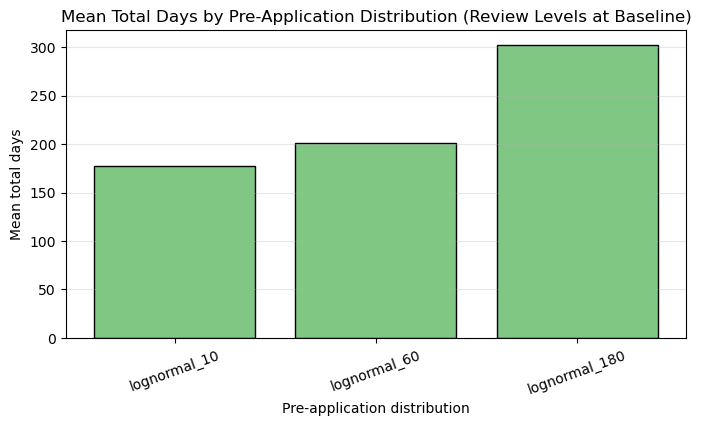

In [5]:
# Optional visualization: compare pre-application distributions at baseline review levels
plot_df = summary[
    (summary["planning_level"] == 1.0)
    & (summary["public_works_level"] == 1.0)
    & (summary["fire_level"] == 1.0)
    & (summary["special_zoning_level"] == 1.0)
    & (summary["agency_referral_level"] == 1.0)
].copy()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    plot_df["pre_application_distribution"],
    plot_df["mean_total_days"],
    color="#81C784",
    edgecolor="black",
)
ax.set_title("Mean Total Days by Pre-Application Distribution (Review Levels at Baseline)")
ax.set_xlabel("Pre-application distribution")
ax.set_ylabel("Mean total days")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20)
plt.show()

In [6]:
# Export CSV outputs (every run + grouped summary)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
runs_csv = f"sensitivity_runs_all_combinations_{timestamp}.csv"
summary_csv = f"sensitivity_summary_all_combinations_{timestamp}.csv"

results_df.to_csv(runs_csv, index=False)
summary.to_csv(summary_csv, index=False)

print(f"Saved per-run results: {runs_csv}")
print(f"Saved grouped summary: {summary_csv}")
print(f"Per-run rows exported: {len(results_df)}")
print(f"Unique parameter combinations: {summary.shape[0]}")

summary.head()

Saved per-run results: sensitivity_runs_all_combinations_20260419_135307.csv
Saved grouped summary: sensitivity_summary_all_combinations_20260419_135307.csv
Per-run rows exported: 7290
Unique parameter combinations: 729


,pre_application_distribution,planning_level,public_works_level,fire_level,special_zoning_level,agency_referral_level,planning_staff_count,public_works_staff_count,fire_staff_count,n_runs_proxy,seed,completed_permits,mean_total_days,mean_application_to_ready_days,planning_to_ready_n,debris_blocking_wait_count,debris_blocking_wait_share,debris_blocking_wait_mean_days,debris_blocking_wait_median_days,debris_blocking_wait_max_days,median_total_days,std_total_days,min_total_days,max_total_days,mean_wait_days,mean_service_days,county_review_mean,applicant_mean,debris_mean,step_wait_mean__epa_debris,step_service_mean__epa_debris,step_wait_mean__usace_debris,step_service_mean__usace_debris,step_wait_mean__pre_application_activities,step_service_mean__pre_application_activities,step_wait_mean__applicant_revisions,step_service_mean__applicant_revisions,step_wait_mean__planning,step_service_mean__planning,step_wait_mean__agency_referral,step_service_mean__agency_referral,step_wait_mean__special_zoning,step_service_mean__special_zoning,step_wait_mean__public_works,step_service_mean__public_works,step_wait_mean__fire_review,step_service_mean__fire_review
0,lognormal_10,0.5,0.5,0.5,0.5,0.5,4.0,8.0,4.0,4.5,46.5,1200.0,156.662927,145.096385,1200.0,5.9,0.004917,10.008470,8.313668,20.529849,155.195208,57.174524,22.471901,377.661587,78.840077,97.450826,86.837889,74.600315,14.852699,3.145482,0.998964,8.210169,2.498083,0.0,11.566542,0.0,63.033773,67.477849,3.397923,0.0,3.821804,0.0,5.657351,0.000248,4.150675,0.006329,2.325711
1,lognormal_10,0.5,0.5,0.5,0.5,1.0,4.0,8.0,4.0,4.5,46.5,1200.0,158.822278,147.255737,1200.0,5.8,0.004833,10.049509,8.391778,20.529849,157.011567,59.246854,22.471901,437.500971,78.840077,101.272629,90.659693,74.600315,14.852699,3.145482,0.998964,8.210169,2.498083,0.0,11.566542,0.0,63.033773,67.477849,3.397923,0.0,7.643607,0.0,5.657351,0.000248,4.150675,0.006329,2.325711
2,lognormal_10,0.5,1.0,0.5,0.5,0.5,4.0,16.0,4.0,4.5,46.5,1200.0,161.475949,149.909408,1200.0,3.5,0.002917,9.580472,8.398299,15.988050,160.150333,57.176407,24.527888,369.392537,79.239553,102.227281,91.415830,75.184992,14.866012,3.156756,1.002453,8.207886,2.498917,0.0,11.566542,0.0,63.618450,67.870834,3.397754,0.0,3.789674,0.0,5.726607,0.000297,8.336705,0.003779,2.290179
3,lognormal_10,0.5,0.5,0.5,1.0,0.5,4.0,8.0,4.0,4.5,46.5,1200.0,162.898009,151.331467,1200.0,6.4,0.005333,9.671901,8.423830,19.112073,160.439424,63.261210,23.280160,498.774493,78.827730,103.779041,92.615595,75.137811,14.853366,3.145600,1.000679,8.210169,2.496917,0.0,11.566542,0.0,63.571269,67.468204,3.402294,0.0,3.767086,0.0,11.456714,0.000495,4.159922,0.003261,2.357619
4,lognormal_10,1.0,0.5,0.5,0.5,0.5,8.0,8.0,4.0,4.5,46.5,1200.0,163.382252,151.815710,1200.0,2.9,0.002417,9.667159,9.077817,16.269881,161.955655,59.942398,25.847223,368.088180,81.762075,101.212147,93.066814,75.051724,14.855684,3.162055,1.002451,8.195679,2.495500,0.0,11.566542,0.0,63.485183,70.401315,6.797049,0.0,3.671156,0.0,5.709685,0.000396,4.152824,0.002630,2.331757
